In [99]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import *
from sklearn.decomposition import *
from sklearn.preprocessing import *

plt.style.use("dark_background")

In [100]:
train = pd.read_csv("train.csv");
test = pd.read_csv("test.csv");

In [101]:
train

,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,0,55,165,60,81.0,0.5,0.6,1,1,135,87,94,172,300,40,75,16.5,1,1.0,22,25,27,0,1
1,1,70,165,65,89.0,0.6,0.7,2,2,146,83,147,194,55,57,126,16.2,1,1.1,27,23,37,1,0
2,2,20,170,75,81.0,0.4,0.5,1,1,118,75,79,178,197,45,93,17.4,1,0.8,27,31,53,0,1
3,3,35,180,95,105.0,1.5,1.2,1,1,131,88,91,180,203,38,102,15.9,1,1.0,20,27,30,1,0
4,4,30,165,60,80.5,1.5,1.0,1,1,121,76,91,155,87,44,93,15.4,1,0.8,19,13,17,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159251,159251,40,155,45,69.0,1.5,2.0,1,1,127,80,64,238,47,72,159,14.5,1,0.8,25,26,13,0,0
159252,159252,50,155,75,82.0,1.0,1.0,1,1,120,80,89,213,202,64,108,14.5,1,0.6,21,20,18,0,0
159253,159253,40,160,50,66.0,1.5,1.0,1,1,114,70,84,189,45,87,93,10.9,1,0.6,15,9,12,0,0
159254,159254,50,165,75,92.0,1.2,1.0,1,1,121,90,122,165,148,55,80,14.4,1,1.1,22,17,37,0,1


In [102]:
train.corr().style.background_gradient(cmap='coolwarm')

,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
id,1.000000,-0.003724,0.000710,-0.001656,-0.003491,0.002325,0.001222,-0.003876,-0.003448,0.000107,0.000119,0.000618,-0.001530,-0.001875,0.003049,-0.003059,0.000834,-0.000900,-0.001278,0.000685,-0.000270,0.006935,-0.001382,-0.000632
age,-0.003724,1.000000,-0.489608,-0.336859,-0.045369,-0.269495,-0.277638,0.212889,0.212972,0.160437,0.064924,0.191913,0.106873,-0.038063,0.041411,0.103529,-0.280851,-0.004526,-0.143808,0.036595,-0.131419,-0.046879,-0.120556,-0.206033
height(cm),0.000710,-0.489608,1.000000,0.686645,0.409500,0.209997,0.216729,-0.090110,-0.091760,0.062297,0.114390,0.017516,-0.113455,0.252464,-0.303450,-0.080001,0.568739,-0.015097,0.459654,0.059126,0.222305,0.218809,0.100585,0.447111
weight(kg),-0.001656,-0.336859,0.686645,1.000000,0.830208,0.151794,0.161344,-0.069761,-0.070679,0.241495,0.265921,0.132409,0.020382,0.384313,-0.438224,0.059438,0.527259,-0.028537,0.391769,0.160221,0.376899,0.290996,0.091375,0.351748
waist(cm),-0.003491,-0.045369,0.409500,0.830208,1.000000,0.046964,0.055094,0.004759,0.006637,0.306150,0.291389,0.209541,0.075039,0.394593,-0.449219,0.114552,0.418245,-0.029491,0.294176,0.185690,0.359736,0.294166,0.053575,0.262715
eyesight(left),0.002325,-0.269495,0.209997,0.151794,0.046964,1.000000,0.448945,-0.067788,-0.070379,-0.030718,0.010324,-0.048066,-0.014211,0.057775,-0.043069,-0.018312,0.134314,-0.011633,0.089165,-0.000032,0.063819,0.041759,0.020019,0.100420
eyesight(right),0.001222,-0.277638,0.216729,0.161344,0.055094,0.448945,1.000000,-0.072888,-0.078285,-0.026931,0.017073,-0.047424,-0.011569,0.063572,-0.047384,-0.016913,0.140602,-0.011213,0.087232,0.007967,0.073843,0.052901,0.024314,0.109781
hearing(left),-0.003876,0.212889,-0.090110,-0.069761,0.004759,-0.067788,-0.072888,1.000000,0.553312,0.041887,-0.011739,0.025334,-0.029430,-0.035088,-0.004135,-0.011467,-0.051724,-0.007248,-0.009447,-0.003497,-0.036896,-0.021820,-0.019155,-0.038219
hearing(right),-0.003448,0.212972,-0.091760,-0.070679,0.006637,-0.070379,-0.078285,0.553312,1.000000,0.041790,-0.015248,0.024982,-0.029276,-0.034343,-0.003311,-0.012463,-0.049649,-0.004164,-0.009263,-0.001232,-0.036679,-0.017286,-0.016100,-0.036858
systolic,0.000107,0.160437,0.062297,0.241495,0.306150,-0.030718,-0.026931,0.041887,0.041790,1.000000,0.753003,0.176127,0.069044,0.161187,-0.116457,0.052032,0.174904,-0.029040,0.066902,0.092272,0.109954,0.159811,0.018136,0.058642


In [103]:
train_labels = train["smoking"]

test_ids = test["id"]

drop_cols = ["id"];

train.drop(columns="smoking", inplace=True);
train.drop(columns=drop_cols, inplace=True);
test.drop(columns=drop_cols, inplace=True);

In [104]:
scl = MinMaxScaler().fit(pd.concat([train, test]));

train = pd.DataFrame(scl.transform(train), train.index, train.columns)
test = pd.DataFrame(scl.transform(test), test.index, test.columns)


In [105]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import *


# selector = RFE(ExtraTreesRegressor(n_estimators=100, n_jobs=-1, verbose=1), n_features_to_select=7).fit(train, train_labels)

# train = selector.transform(train)
# test = selector.transform(test)

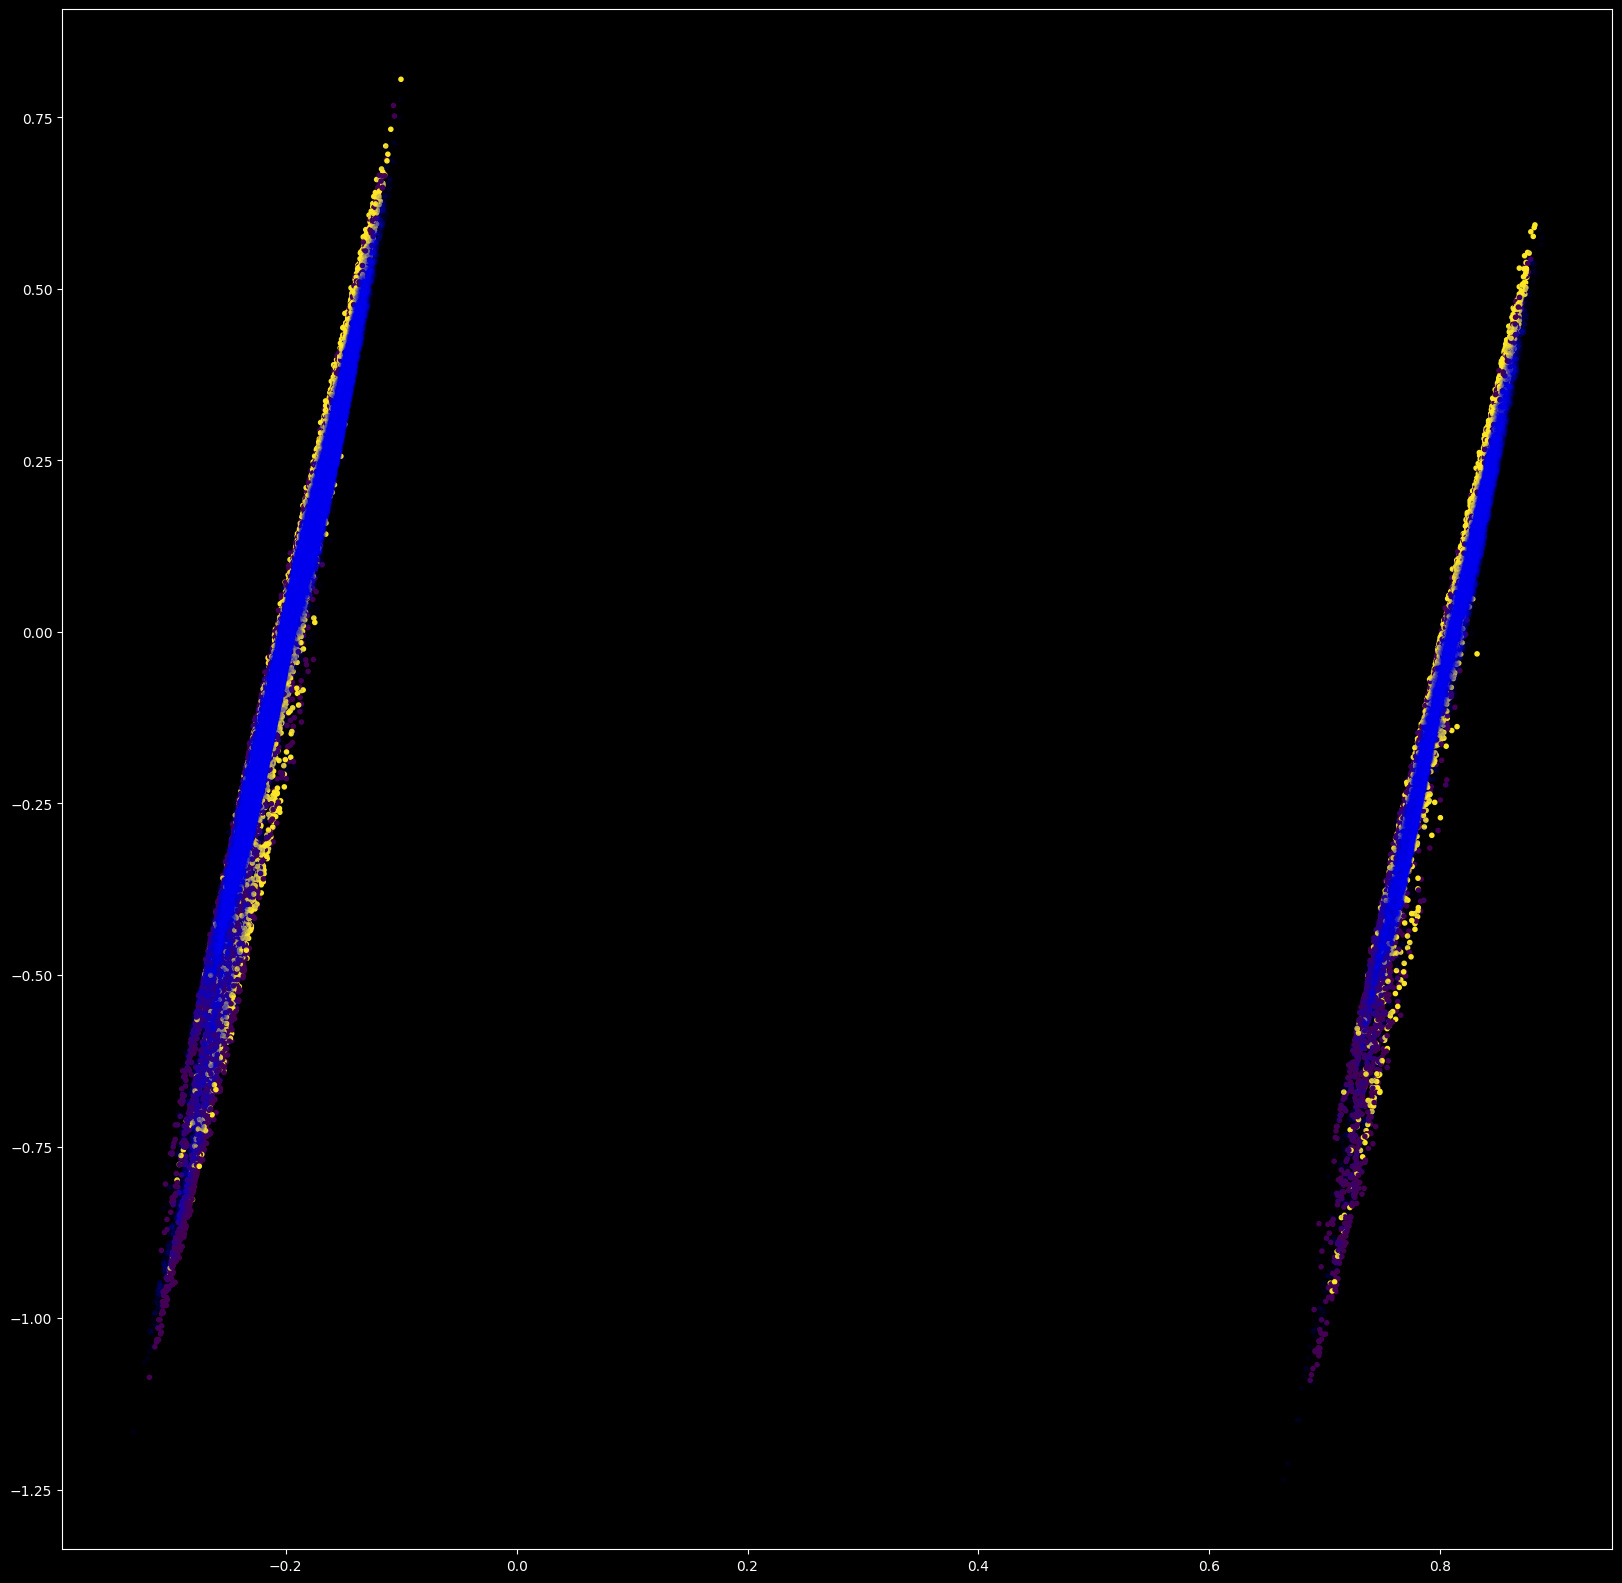

In [106]:
points_train = PCA(2).fit_transform(train)
points_test = PCA(2).fit_transform(test)

plt.figure(figsize=(20, 20))

plt.scatter(points_train[:, 0], points_train[:, 1], c=train_labels, marker='.')
plt.scatter(points_test[:, 0], points_test[:, 1], c="blue", marker='.', alpha=0.06)

In [107]:
# train = pd.read_csv("train_feature_extraction.csv");
# test = pd.read_csv("test_feature_extraction.csv");

# train_labels = pd.read_csv("train.csv")["smoking"]

In [108]:
# model = GradientBoostingClassifier(n_estimators=2000, verbose=1, learning_rate=0.001).fit(train, train_labels)
from sklearn.svm import SVC
import catboost
params = {
    'iterations': 2000,
    'learning_rate': 0.01,
    'depth': 10,
    'random_state': 42,
}

model = catboost.CatBoostClassifier(**params).fit(train, train_labels)

0:	learn: 0.6873137	total: 73.7ms	remaining: 2m 27s
1:	learn: 0.6817900	total: 127ms	remaining: 2m 7s
2:	learn: 0.6764245	total: 173ms	remaining: 1m 55s
3:	learn: 0.6710851	total: 219ms	remaining: 1m 49s
4:	learn: 0.6660662	total: 273ms	remaining: 1m 48s
5:	learn: 0.6611049	total: 331ms	remaining: 1m 50s
6:	learn: 0.6562555	total: 387ms	remaining: 1m 50s
7:	learn: 0.6514941	total: 426ms	remaining: 1m 46s
8:	learn: 0.6469769	total: 465ms	remaining: 1m 42s
9:	learn: 0.6426824	total: 500ms	remaining: 1m 39s
10:	learn: 0.6385101	total: 532ms	remaining: 1m 36s
11:	learn: 0.6342755	total: 574ms	remaining: 1m 35s
12:	learn: 0.6300826	total: 628ms	remaining: 1m 35s
13:	learn: 0.6260343	total: 669ms	remaining: 1m 34s
14:	learn: 0.6220849	total: 708ms	remaining: 1m 33s
15:	learn: 0.6183664	total: 768ms	remaining: 1m 35s
16:	learn: 0.6148305	total: 803ms	remaining: 1m 33s
17:	learn: 0.6113481	total: 835ms	remaining: 1m 31s
18:	learn: 0.6077429	total: 869ms	remaining: 1m 30s
19:	learn: 0.6043592	t

In [109]:
pred = model.predict_proba(test)

In [110]:
pred

array([[0.39755639, 0.60244361],
       [0.7761013 , 0.2238987 ],
       [0.55180587, 0.44819413],
       ...,
       [0.56186995, 0.43813005],
       [0.89759605, 0.10240395],
       [0.96896248, 0.03103752]])

In [111]:
test_ids = pd.read_csv("test.csv")["id"]

In [112]:
ans = pd.DataFrame();
ans["id"] = test_ids;
ans["smoking"] = pred[:, 1];
ans.to_csv("ans.csv", index=False);